COLAB B — PyTorch From Scratch (Manual 3-Layer DNN)

Cell 1 — Install & Imports

In [2]:
!pip install torch torchvision scikit-learn matplotlib --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(42)
np.random.seed(42)

Cell 2 — Generate Synthetic 3-Variable Data

Use the same nonlinear regression target:
y=sin(x1​)+x22​+log(x32​+1)

In [3]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32)

X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y.reshape(-1,1))

Cell 3 — Define Model Parameters From Scratch

No nn.Linear, no nn.Module.

Architecture:

Input: 3

Hidden1: 64 neurons (ReLU)

Hidden2: 32 neurons (Tanh)

Output: 1 neuron (linear)

In [10]:
# Dimensions
input_dim = 3
h1 = 64
h2 = 32
output_dim = 1

# Initialize weights properly (leaf tensors)
W1 = torch.randn(input_dim, h1) * 0.1
W1.requires_grad_()
b1 = torch.zeros(h1, requires_grad=True)

W2 = torch.randn(h1, h2) * 0.1
W2.requires_grad_()
b2 = torch.zeros(h2, requires_grad=True)

W3 = torch.randn(h2, output_dim) * 0.1
W3.requires_grad_()
b3 = torch.zeros(output_dim, requires_grad=True)

lr = 1e-3

Cell 4 — Forward Pass (Manual)

No built-in layers.

In [5]:
def forward(X):
    # Layer 1
    z1 = X @ W1 + b1
    a1 = torch.relu(z1)

    # Layer 2
    z2 = a1 @ W2 + b2
    a2 = torch.tanh(z2)

    # Output
    out = a2 @ W3 + b3
    return z1, a1, z2, a2, out

Cell 5 — Loss Function (MSE)

In [6]:
def mse_loss(pred, target):
    return torch.mean((pred - target)**2)

Cell 6 — Training Loop

Manually update parameters using autograd.

In [11]:
epochs = 500
losses = []

for epoch in range(epochs):

    # Forward pass
    z1, a1, z2, a2, preds = forward(X_tensor)
    loss = mse_loss(preds, y_tensor)

    # Backprop
    loss.backward()

    # Manual gradient descent
    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad
        W3 -= lr * W3.grad
        b3 -= lr * b3.grad

        # Clear gradients
        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()
        W3.grad.zero_()
        b3.grad.zero_()

    losses.append(loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 6.054570
Epoch 50, Loss: 4.548263
Epoch 100, Loss: 3.400302
Epoch 150, Loss: 2.581213
Epoch 200, Loss: 2.069609
Epoch 250, Loss: 1.788187
Epoch 300, Loss: 1.642794
Epoch 350, Loss: 1.564347
Epoch 400, Loss: 1.514971
Epoch 450, Loss: 1.477402


Cell 7 — Plot Training Loss

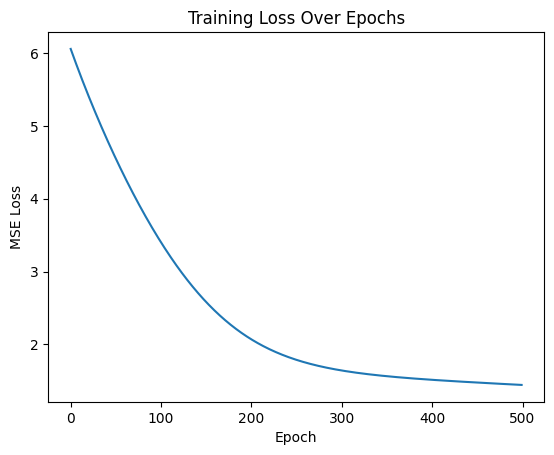

In [12]:
plt.plot(losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Cell 8 — True vs Predicted Scatter

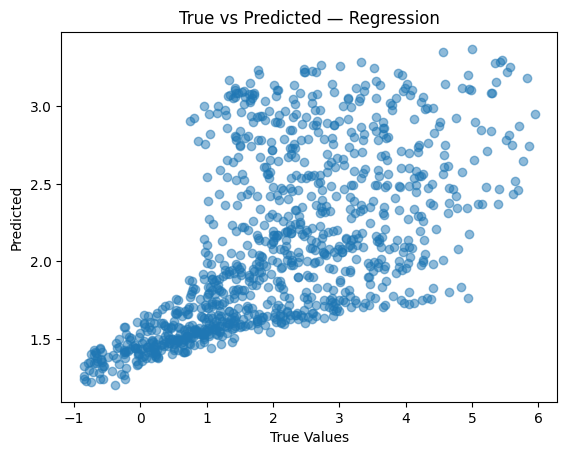

In [13]:
_, _, _, _, preds_final = forward(X_tensor)

plt.scatter(y, preds_final.detach().numpy(), alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted")
plt.title("True vs Predicted — Regression")
plt.show()

Cell 9 — 4D Visualization Using PCA

Reduce the 3D input (x1,x2,x3) into 2 principal components for 3D plotting.

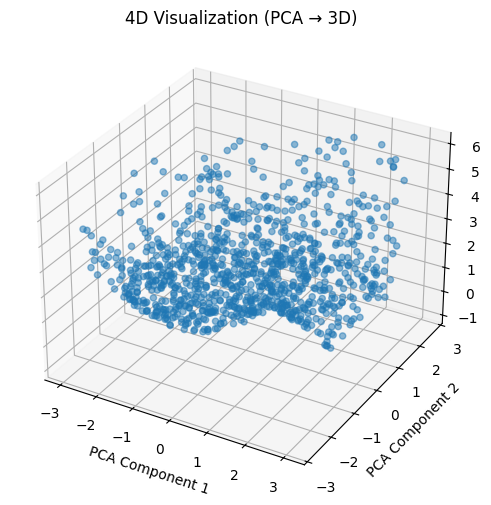

In [14]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Output")
plt.title("4D Visualization (PCA → 3D)")
plt.show()